## Attention vs Attribution: When Does Attention Explain Predictions?

### Learning Objectives

By the end of this notebook, you will be able to:

1. **Visualize self-attention** using BertViz to inspect token-routing patterns across all heads and layers of BERT
2. **Compute gradient-based attribution** using input-embedding gradients to measure per-token predictive influence
3. **Contrast attention and attribution**: understand why attention weights ≠ causal importance, and when the two align or diverge
4. **Quantify alignment** between attention and gradient attribution via Pearson correlation across all 12 transformer layers
5. **Run clause-level counterfactual experiments** to probe how discourse connectives ("but" vs "and") reshape both the prediction and the attribution signal

**Key insight:** Attention tells you *where the model routed information*; attribution tells you *what changed the prediction*. These often diverge — and this notebook shows you exactly when and why.

| Method | What it measures | Pros | Cons |
|--------|-----------------|------|------|
| **Attention weights** | Internal information routing between tokens | Fast, no backprop needed; visually interpretable | Not causally grounded; can be misleading |
| **Gradient attribution** | Sensitivity of the logit to each input token | Causally meaningful; backed by theory | Always ≥ 0 (L2 norm); can be noisy |

## Attention as Mechanism (BertViz)

We visualize self-attention to inspect how tokens interact across layers.

Important:
Attention weights reflect internal routing patterns, not guaranteed causal explanations.
We use this tool to understand model structure and compare it against attribution-based methods.

We will:
1. Visualize attention patterns.
2. Identify syntactic and semantic attention behaviors.
3. Compare attention patterns to gradient-based attribution.

In [ ]:
import os; os.environ.setdefault('HF_HUB_DISABLE_XET', '1')  # avoid full-repo downloads
# Load Model (Use a Modern Model)
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F  # noqa: N812
from bertviz import head_view, model_view
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, utils


utils.logging.set_verbosity_error()

In [ ]:
CACHE_DIR = None  # Can be set to a specific directory to cache models, e.g., "./cache"
MODEL_NAME = "textattack/bert-base-uncased-SST-2"  # "distilbert-base-uncased-finetuned-sst-2-english", # "textattack/bert-base-uncased-SST-2" # "microsoft/deberta-v3-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True, cache_dir=CACHE_DIR)
model.to(device)
model.eval()

In [4]:
# Analyze Cross-Token Patterns
# Add a sentence with ambiguity:
# text = "The engineer told the manager that he was late."
text = "The engineer was brilliant but the manager was incompetent."

**Questions to investigate with this sentence:**
- Which tokens receive the most attention from `[CLS]` in the final layer?
- Does the model attend more to *brilliant* (positive) or *incompetent* (negative)?
- Do attention patterns shift depending on which clause comes first?

In [6]:
inputs = tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# We visualize encoder self-attention across all heads and layers.
attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

model_view(attention, tokens)

<IPython.core.display.Javascript object>

In [7]:
print(len(attention))  # number of layers
head_view(attention, tokens, layer=11)

12


<IPython.core.display.Javascript object>

## Section 2: Gradient-Based Attribution

In [ ]:
# Load SAME backbone as attention section
clf_model = AutoModelForSequenceClassification.from_pretrained(
    "textattack/bert-base-uncased-SST-2",  # "distilbert-base-uncased-finetuned-sst-2-english",
    output_attentions=True,
    cache_dir=CACHE_DIR,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clf_model.to(device)
clf_model.eval()
print("Model loaded")

In [ ]:
def gradient_token_importance(text, target_class=None):
    device = next(clf_model.parameters()).device

    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # Get embeddings
    embeddings = clf_model.get_input_embeddings()(input_ids)
    embeddings.requires_grad_(True)
    embeddings.retain_grad()

    outputs = clf_model(inputs_embeds=embeddings, attention_mask=attention_mask)

    # Automatically use predicted class if not specified
    if target_class is None:
        target_class = torch.argmax(outputs.logits, dim=-1).item()

    clf_model.zero_grad()
    logit = outputs.logits[0, target_class]
    logit.backward()

    grads = embeddings.grad[0]  # (seq_len, hidden_dim)
    token_importance = torch.norm(grads, dim=1).detach().cpu().numpy()

    # Normalize across sentence (L2)
    token_importance = token_importance / (np.linalg.norm(token_importance) + 1e-8)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return tokens, token_importance


def visualize_token_importance(tokens, scores, title=None):
    """Bar chart of gradient-based token attribution.

    Note: scores are L2 norms of embedding gradients (always >= 0),
    so all bars represent the *magnitude* of gradient influence —
    not direction. Higher = more influence on the prediction.
    """
    scores = np.array(scores, dtype=float)
    fig, ax = plt.subplots(figsize=(max(6, len(tokens) * 0.9), 3.8))
    ax.bar(tokens, scores, color="#d73027", edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_ylabel("Attribution Score (L2 norm)")
    ax.set_title(title or "Gradient-Based Token Attribution", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=35)
    for i, (_token, s) in enumerate(zip(tokens, scores)):
        ax.text(i, s + 0.005 * (scores.max() + 1e-8), f"{s:.3f}", ha="center", va="bottom", fontsize=7.5, color="black")
    plt.tight_layout()
    plt.show()

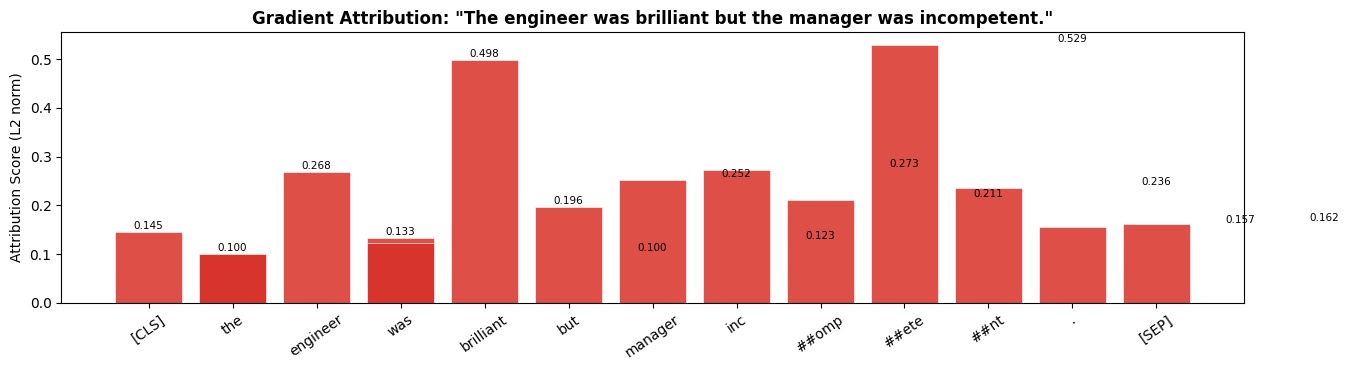

In [10]:
tokens_grad, grad_scores = gradient_token_importance(text)
visualize_token_importance(
    tokens_grad,
    grad_scores,
    title='Gradient Attribution: "The engineer was brilliant but the manager was incompetent."',
)

#### Attention vs Attribution

Attention patterns reveal how information flows between tokens. However, attention weights are not guaranteed to reflect causal importance.

Gradient-based attribution measures sensitivity of the prediction. Comparing the two reveals where architectural routing diverges from decision influence.

#### Observation: Attention–Attribution Misalignment at Layer 11

The average Pearson correlation across all 12 heads at layer 11 is **-0.16**, indicating that CLS-row attention and gradient-based attribution are largely misaligned at the final layer. Most heads show negative correlation — they tend to attend to tokens that *least* drive the prediction according to the gradient signal.

This is a concrete demonstration of the core claim in *Jain & Wallace (2019)*: attention is not explanation. Just because a token receives high attention weight does not mean it is causally important for the output.

> **Note:** A few heads do show positive correlation (e.g., head 6 ≈ +0.22), suggesting that some heads incidentally align with gradient importance. But the overall picture is noisy and head-dependent, not systematic.

In [11]:
# Quantify alignment between attention and gradient importance.

# Find CLS index
cls_index = tokens.index("[CLS]")

grad_norm = grad_scores / (np.linalg.norm(grad_scores) + 1e-8)

layer = 11
num_heads = attention[layer].shape[1]

head_correlations = []

for head in range(num_heads):
    att_matrix = attention[layer][0][head].detach().cpu().numpy()

    # CLS attention distribution
    cls_attention = att_matrix[cls_index]

    corr = np.corrcoef(cls_attention, grad_norm)[0, 1]
    head_correlations.append(corr)

print("Head-wise correlations:", head_correlations)
print("Average correlation (layer 11):", np.mean(head_correlations))

Head-wise correlations: [-0.26548058313153955, -0.14269560571737805, -0.24917887720427423, -0.22741604191423198, -0.32319097107513856, -0.32594690093267364, 0.2184264545353714, -0.45618820366387336, -0.11096726941824782, 0.05679428521294339, -0.026206622892481105, -0.052327932496510667]
Average correlation (layer 11): -0.15869818905816951


In [12]:
# full layer alignment
num_layers = len(attention)
layer_means = []

for layer in range(num_layers):
    num_heads = attention[layer].shape[1]
    head_corrs = []

    for head in range(num_heads):
        att_matrix = attention[layer][0][head].detach().cpu().numpy()
        cls_attention = att_matrix[cls_index]

        valid_indices = [i for i, t in enumerate(tokens) if t not in ["[CLS]", "[SEP]"]]

        cls_attention = cls_attention[valid_indices]
        grad_valid = grad_norm[valid_indices]
        corr = np.corrcoef(cls_attention, grad_valid)[0, 1]
        head_corrs.append(corr)

    layer_means.append(np.mean(head_corrs))

print("Layer-wise mean correlations:")
for i, val in enumerate(layer_means):
    print(f"Layer {i}: {val:.4f}")

Layer-wise mean correlations:
Layer 0: -0.1830
Layer 1: -0.3149
Layer 2: -0.3815
Layer 3: -0.1609
Layer 4: 0.0608
Layer 5: 0.0524
Layer 6: 0.0904
Layer 7: 0.0637
Layer 8: -0.0295
Layer 9: -0.1190
Layer 10: -0.0693
Layer 11: -0.1547


### Layer-wise Attention–Attribution Alignment

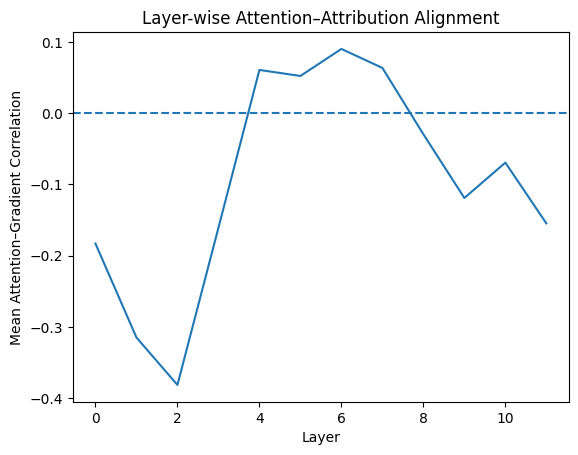

In [13]:
# Visualize Alignment Trend
plt.plot(range(num_layers), layer_means)
plt.xlabel("Layer")
plt.ylabel("Mean Attention–Gradient Correlation")
plt.title("Layer-wise Attention–Attribution Alignment")
plt.axhline(0, linestyle="--")
plt.show()

#### Observation: Layer-wise Attention–Attribution Alignment

The layer-wise correlation analysis reveals that attention–attribution alignment is **weak and mostly negative** throughout the network for this sentence:

| Layer range | Pattern | Interpretation |
|-------------|---------|----------------|
| Layers 0–2 | Strongly negative (−0.18 to −0.38) | Early attention focuses on positional and syntactic routing, attending to tokens that are *not* driving the prediction |
| Layers 4–7 | Near zero, slightly positive (~0.05–0.09) | Mid-depth layers begin to capture semantic content; partial alignment with gradient signal emerges |
| Layers 8–11 | Negative again (−0.03 to −0.15) | Final layers aggregate into CLS via pooler; token-level attention diverges from per-token gradient influence |

**Overall takeaway:** On a single contrastive sentence, gradient importance is dominated by a few high-sentiment tokens (*brilliant*, *incompetent*), while attention spreads across many tokens for syntactic and contextual integration. The two signals measure fundamentally different things — routing vs. sensitivity — and there is no strong systematic alignment between them.

## Clause-Level Counterfactual Experiment

In [ ]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt")

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = clf_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = F.softmax(outputs.logits, dim=-1)

    return probs[0].cpu().numpy()

In [ ]:
A = "The engineer was brilliant but the manager was incompetent."
B = "The manager was incompetent but the engineer was brilliant."
C = "The engineer was brilliant and the manager was incompetent."

print("A probs:", predict(A))
print("B probs:", predict(B))
print("C probs:", predict(C))

In [17]:
def top_k_tokens(tokens, scores, k=3):
    pairs = list(zip(tokens, scores))
    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:k]

In [ ]:
# Sentence A
tokens_a, scores_a = gradient_token_importance(A)
top3_a = top_k_tokens(tokens_a, scores_a, 3)

# Sentence B
tokens_b, scores_b = gradient_token_importance(B)
top3_b = top_k_tokens(tokens_b, scores_b, 3)

# Sentence C
tokens_c, scores_c = gradient_token_importance(C)
top3_c = top_k_tokens(tokens_c, scores_c, 3)

print("Sentence A probs:", predict(A))
print("Sentence A top-3 tokens:", top3_a)

print("\nSentence B probs:", predict(B))
print("Sentence B top-3 tokens:", top3_b)

print("\nSentence C probs:", predict(C))
print("Sentence C top-3 tokens:", top3_c)

In [ ]:
# Side-by-side attribution comparison across counterfactual sentences
probs_a = predict(A)
probs_b = predict(B)
probs_c = predict(C)

all_token_sets = [tokens_a, tokens_b, tokens_c]
all_score_sets = [scores_a, scores_b, scores_c]
sentence_labels = ["A", "B", "C"]
titles = [
    f"A: '...brilliant but...incompetent'\nPredicted: Negative ({probs_a[0]:.2f})",
    f"B: '...incompetent but...brilliant'\nPredicted: Positive ({probs_b[1]:.2f})",
    f"C: '...brilliant and...incompetent'\nPredicted: Negative ({probs_c[0]:.2f})",
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, toks, scores, title in zip(axes, all_token_sets, all_score_sets, titles):
    # exclude [CLS] and [SEP]
    filtered = [(t, s) for t, s in zip(toks, scores) if t not in ["[CLS]", "[SEP]"]]
    t_labels, t_scores = zip(*filtered)
    bars = ax.bar(t_labels, t_scores, color="#d73027", edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.set_ylabel("Attribution Score")
    ax.set_ylim(0, max(t_scores) * 1.25)
    for bar, s in zip(bars, t_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            s + 0.008 * max(t_scores),
            f"{s:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

fig.suptitle(
    "Attribution Across Counterfactual Sentences\n(Discourse connective changes which clause dominates)",
    fontsize=11,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

#### Clause Sensitivity and Discourse Dominance

The model exhibits strong discourse sensitivity: in sentences containing a contrastive conjunction (“but”), the clause following “but” dominates the sentiment prediction. Reversing clause order flips the model’s decision with near certainty, demonstrating that the model has internalized a contrastive semantic pattern rather than simply aggregating sentiment words.

In contrast, replacing “but” with “and” reduces polarity dominance, leading to a less extreme prediction. This confirms that attention and attribution analyses must be interpreted in the context of discourse structure, not isolated token sentiment strength.

## Key Takeaways

### What we found

| Finding | Evidence |
|---------|----------|
| **Attention ≠ attribution** | CLS-row attention at layer 11 has mean correlation −0.16 with gradient importance |
| **Early layers are worst** | Layers 0–2 show strongest negative alignment (−0.38) — purely syntactic routing |
| **Mid-depth shows slight alignment** | Layers 4–7 are closest to zero, with minor positive values (~0.09 max) |
| **Discourse connectives matter** | "but" vs "and" changes both the prediction confidence and the attribution pattern |
| **Clause order dominates with "but"** | Swapping "brilliant but incompetent" → "incompetent but brilliant" flips the prediction entirely |
| **Gradient norms are always ≥ 0** | L2 norms measure magnitude only — they cannot tell you the sign of a token's effect |

### When to use each method

| Question | Use Attention | Use Attribution |
|---------|:---:|:---:|
| How does token A route information to token B? | ✓ | ✗ |
| Which tokens most influence the final prediction? | ✗ | ✓ |
| What syntactic patterns did the model learn? | ✓ | Partial |
| If token X changed, would the prediction change? | ✗ | ✓ |
| Quick model inspection without backprop? | ✓ | ✗ |

### Reflection Questions

1. Why might high attention weight on a token *not* imply it drives the prediction?
2. In sentence B ("incompetent but brilliant"), which tokens get the highest attribution? Does this make sense?
3. What would you expect to see if you replaced *incompetent* with a neutral word like *present*? Would "but" still dominate?
4. Integrated Gradients (Sundararajan et al., 2017) is considered more principled than raw input gradients — what property does it satisfy that raw gradients do not?

## References

- Jain, Sarthak, and Byron C. Wallace. "Attention is not explanation." *Proceedings of NAACL-HLT*, 2019. Demonstrated that attention weights often fail to correlate with gradient-based feature importance and can be arbitrarily permuted without changing predictions.

- Wiegreffe, Sarah, and Yuval Pinter. "Attention is not not explanation." *Proceedings of EMNLP-IJCNLP*, 2019. Challenged Jain & Wallace, arguing that attention can serve as a faithful explanation under certain conditions and that the debate requires more precise definitions.

- Sundararajan, Mukund, Ankur Taly, and Qiqi Yan. "Axiomatic attribution for deep networks." *International Conference on Machine Learning (ICML)*, PMLR, 2017. Introduced Integrated Gradients — a principled gradient attribution method satisfying *completeness* and *sensitivity* axioms.

- Vig, Jesse. "A multiscale visualization of attention in the transformer model." *Proceedings of ACL: System Demonstrations*, 2019. Introduced BertViz, the visualization library used in Section 1 of this notebook.

- Vaswani, Ashish, et al. "Attention is all you need." *Advances in Neural Information Processing Systems (NeurIPS)*, 30, 2017. Original Transformer paper introducing scaled dot-product self-attention.